
<div style="color:#3c4d5a; border-top:7px solid #42A5F5; border-bottom:7px solid #42A5F5; padding:8px; text-align:center; text-transform:uppercase">
  <h1>Predicción de nuevos ejemplos y simulación del agente de streaming adaptativo</h1>
</div>

**Proyecto:** Streaming Adaptativo mediante Machine Learning  
**Integrantes:** Alexis Guamán y Cinthya Ramón

---
<div id="descripcion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Descripción</h2> </div>
Este cuaderno se enfoca en la inferencia utilizando los dos modelos supervisados previamente entrenados (Reactivo y Predictivo) para determinar el perfil de transmisión adecuado en tiempo real y simular el comportamiento del agente de streaming adaptativo.

---
<div id="objetivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Objetivo</h2> </div>
Crear un pipeline de inferencia que cargue los modelos y aplique una lógica de decisión con histéresis, validando su comportamiento con casos reales e hipotéticos antes de la integración en producción.

---
<div id="fases" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fases del Proyecto</h2> </div>
1. Preparación de datos (Completado)
2. Entrenamiento de modelos (Completado)
3. **Inferencia y simulación de agente (Actual)**
4. Integración con entorno real (Futuro)

---
<div id="contenido" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Tabla de Contenido</h2> </div>
1. [Configuración Inicial](#1.-Configuración-Inicial)
2. [Fundamentos de Inferencia](#2.-Fundamentos-de-Inferencia)
3. [Carga de Metadatos y Modelos](#3.-Carga-de-Metadatos-y-Modelos)
4. [Validación de Entradas](#4.-Validación-de-Entradas)
5. [Funciones de Inferencia](#5.-Funciones-de-Inferencia)
6. [Lógica de Decisión del Agente](#6.-Lógica-de-Decisión-del-Agente)
7. [Reglas y Condiciones Críticas](#7.-Reglas-y-Condiciones-Críticas)
8. [Casos de Prueba (Reales e Hipotéticos)](#8.-Casos-de-Prueba-(Reales-e-Hipotéticos))
9. [Simulación Secuencial](#9.-Simulación-Secuencial)
10. [Medición de Inferencia](#10.-Medición-de-Inferencia)
11. [Actualización de Metadatos y Guardado de Resultados](#11.-Actualización-de-Metadatos-y-Guardado-de-Resultados)
12. [Conclusiones y Limitaciones](#12.-Conclusiones-y-Limitaciones)



<div id="1_configuracion_inicial" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>1. Configuración Inicial</h2> </div>
**Qué se realizará:** Importación de librerías, configuración de semillas (RANDOM_STATE=42) y definición de rutas relativas.  
**Por qué es necesario:** Para garantizar reproducibilidad y asegurar que el código funcione tanto desde la raíz como desde la carpeta `notebooks`.


In [1]:

import os
import sys
import json
import pickle
import joblib
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import random
random.seed(RANDOM_STATE)

current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

print(f"Raíz del proyecto: {project_root}")

try:
    import tensorflow as tf
    tf.random.set_seed(RANDOM_STATE)
    print("TensorFlow importado con éxito.")
except ImportError:
    print("TensorFlow no está instalado. No se podrán cargar modelos .keras.")


Raíz del proyecto: C:\Users\kenny\OneDrive\Documents\STREAM-AI\Adaptive-Streaming-ai


TensorFlow importado con éxito.



<div id="2_fundamentos_de_inferencia" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>2. Fundamentos de Inferencia</h2> </div>

- **Inferencia:** Es la fase donde un modelo preentrenado se aplica a datos nuevos (no vistos) para obtener predicciones. A diferencia del entrenamiento, aquí no se calculan gradientes ni se ajustan pesos.
- **Probabilidad de clase y Confianza:** Los algoritmos no solo emiten una clase, sino una distribución de probabilidades. La "confianza" suele ser la probabilidad más alta, indicando qué tan seguro está el modelo de su decisión.
- **Umbral de clasificación:** Particularmente en modelos binarios (como nuestro predictivo), es el límite de probabilidad a partir del cual se asigna la clase positiva (ej. `downgrade_needed`).
- **Streaming Adaptativo:** Técnicas para ajustar la resolución o bitrate de video en tiempo real de acuerdo a la capacidad de la red, garantizando fluidez a costa de compresión.
- **Perfil Actual vs. Recomendado:** El estado en el que transmite OBS actualmente, versus el estado que el agente considera óptimo.
- **Predicción Preventiva:** Actuar antes de que la caída de red se agrave, basándose en la tendencia estadística reciente (historial temporal).
- **Histéresis:** En sistemas de control, es la técnica para evitar oscilaciones rápidas. Para el streaming, significa que el aumento de calidad se ralentiza (requiere tiempo o estabilidad), mientras que la bajada puede ser inmediata por seguridad.
- **Tiempo mínimo entre cambios:** Complemento a la histéresis. Evita saturar al codificador (OBS) con reconfiguraciones por cada segundo.
- **Falsos positivos/negativos:** 
  - Falso Positivo: Reducir la calidad innecesariamente (sacrifica imagen pero salva el flujo).
  - Falso Negativo: Mantener la calidad alta cuando la red cae (causa lag o desconexión). En streaming, un falso negativo es crítico.
- **Decisión basada en dos modelos:** 
  - El modelo **reactivo** responde al estado instantáneo y recomienda niveles absolutos (low, medium, high).
  - El modelo **predictivo** anticipa caídas basándose en el historial y recomienda mantener o degradar.
  - La decisión final es una heurística que fusiona ambas salidas para actuar con prudencia.
  
> **Nota Académica:** Esta fase solo simula decisiones basándose en datos recolectados. Todavía no se cambia automáticamente la configuración de OBS, VDO.Ninja ni MediaMTX.



<div id="3_carga_de_metadatos_y_modelos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>3. Carga de Metadatos y Modelos</h2> </div>
**Qué se realizará:** Lectura de los archivos `.json` que documentan el entrenamiento previo y carga de los modelos preentrenados (Reactivo y Predictivo) mediante `joblib` o `keras`.  
**Por qué es necesario:** No reescribir variables hardcodeadas ni entrenar nuevamente modelos. Si falta un archivo vital, se detendrá el flujo informando explícitamente.


In [2]:

dataset_metadata_path = project_root / "data/processed/dataset_metadata.json"
model_metadata_path = project_root / "models/model_metadata.json"

if not dataset_metadata_path.exists() or not model_metadata_path.exists():
    print(f"Error: Metadatos no encontrados.")
    sys.exit("Faltan archivos de metadatos. Ejecuta Notebook 1 y 2.")

with open(dataset_metadata_path, 'r') as f:
    dataset_metadata = json.load(f)

with open(model_metadata_path, 'r') as f:
    model_metadata = json.load(f)

syn_used = dataset_metadata.get('synthetic_data_used', True)
prod_ready = model_metadata.get('production_ready', True)
reload_ver = model_metadata.get('models_reload_verified', False)
nb2_comp = model_metadata.get('notebook_completed', False)

print("--- Validaciones de Seguridad de Fase ---")
print(f"Datos sintéticos usados: {syn_used}")
print(f"Notebook 2 completado: {nb2_comp}")
print(f"Modelos probados (reload): {reload_ver}")
print(f"Listo para Producción: {prod_ready}")

if syn_used: print("ADVERTENCIA: Se usaron datos sintéticos.")
if not nb2_comp or not reload_ver:
    sys.exit("Error: La fase 2 no finalizó correctamente. Modelos no verificados.")

phase1_ready = model_metadata.get('phase1_ready', False)
if not phase1_ready:
    print("\nADVERTENCIA ACADÉMICA: Phase1_ready es FALSE. Las inferencias serán experimentales. El proyecto no está terminado.")

df_models_info = pd.DataFrame([
    {
        "Modelo": "Reactivo",
        "Algoritmo": model_metadata.get('reactive_model_selected'),
        "Formato": model_metadata.get('reactive_model_format'),
        "Ruta": model_metadata.get('reactive_model_path'),
        "Clases": str(model_metadata.get('reactive_classes')),
        "Variables": len(model_metadata.get('reactive_features', [])),
        "F1 Validacion": model_metadata.get('reactive_validation_metrics', {}).get('Macro_F1'),
        "F1 Test": model_metadata.get('reactive_test_metrics', {}).get('Macro_F1')
    },
    {
        "Modelo": "Predictivo",
        "Algoritmo": model_metadata.get('predictive_model_selected'),
        "Formato": model_metadata.get('predictive_model_format'),
        "Ruta": model_metadata.get('predictive_model_path'),
        "Clases": str(model_metadata.get('predictive_classes')),
        "Variables": len(model_metadata.get('predictive_features', [])),
        "F1 Validacion": model_metadata.get('predictive_validation_metrics', {}).get('Macro_F1'),
        "F1 Test": model_metadata.get('predictive_test_metrics', {}).get('Macro_F1')
    }
])
display(df_models_info)

react_features = model_metadata['reactive_features']
pred_features = model_metadata['predictive_features']
lookback_seconds = model_metadata.get('lookback_seconds', 120)
horizon_seconds = model_metadata.get('horizon_seconds', 180)
predictive_threshold = model_metadata.get('predictive_threshold', 0.5)

print("\n--- Parámetros del Agente Extraídos ---")
print(f"Lookback (s): {lookback_seconds}, Horizon (s): {horizon_seconds}")
print(f"Umbral Predictivo: {predictive_threshold}")
print(f"Perfiles Configurados: {list(model_metadata.get('profile_configuration', {}).keys())}")


--- Validaciones de Seguridad de Fase ---
Datos sintéticos usados: False
Notebook 2 completado: True
Modelos probados (reload): True
Listo para Producción: False


,Modelo,Algoritmo,Formato,Ruta,Clases,Variables,F1 Validacion,F1 Test
0,Reactivo,RandomForest,joblib,models/modelo_reactivo.joblib,"['high', 'low', 'medium']",6,0.996422,0.733871
1,Predictivo,GradientBoosting,joblib,models/modelo_predictivo.joblib,"[0, 1]",20,0.896552,0.733871



--- Parámetros del Agente Extraídos ---
Lookback (s): 120, Horizon (s): 180
Umbral Predictivo: 0.45000000000000007
Perfiles Configurados: ['low', 'medium', 'high']



### Carga Dinámica
Se incluyen funciones reutilizables que detectan la extensión y cargan los modelos/artefactos desde disco.


In [3]:

def cargar_modelo_desde_metadata(model_key_path, model_metadata, project_root):
    ruta_relativa = model_metadata.get(model_key_path)
    if not ruta_relativa:
        raise ValueError(f"La clave {model_key_path} no existe en los metadatos.")
        
    ruta_absoluta = project_root / ruta_relativa
    if not ruta_absoluta.exists():
        raise FileNotFoundError(f"El modelo no existe en {ruta_absoluta}")
        
    ext = ruta_absoluta.suffix.lower()
    if ext == '.joblib':
        print(f"Cargando modelo .joblib desde {ruta_relativa}...")
        return joblib.load(ruta_absoluta)
    elif ext == '.keras':
        print(f"Cargando modelo .keras desde {ruta_relativa}...")
        return tf.keras.models.load_model(ruta_absoluta)
    else:
        raise ValueError(f"Extensión desconocida: {ext}")

def cargar_artefactos(ruta_absoluta):
    if not ruta_absoluta.exists():
        return None
    ext = ruta_absoluta.suffix.lower()
    if ext == '.joblib':
        print(f"Cargando artefacto .joblib desde {ruta_absoluta.name}...")
        return joblib.load(ruta_absoluta)
    elif ext == '.pkl':
        print(f"Cargando artefacto .pkl desde {ruta_absoluta.name}...")
        return joblib.load(ruta_absoluta)
    return None

modelo_reactivo = cargar_modelo_desde_metadata("reactive_model_path", model_metadata, project_root)
modelo_predictivo = cargar_modelo_desde_metadata("predictive_model_path", model_metadata, project_root)

preproc_r = cargar_artefactos(project_root / "models/preprocesador_reactivo.joblib")
preproc_p = cargar_artefactos(project_root / "models/preprocesador_predictivo.joblib")
artef_r = cargar_artefactos(project_root / "models/artefactos_reactivo.pkl")

le_reactivo = artef_r.get("encoder") if artef_r else None
if not le_reactivo:
    raise ValueError("El LabelEncoder del modelo reactivo no fue encontrado en los artefactos.")
else:
    print(f"LabelEncoder cargado exitosamente. Clases: {le_reactivo.classes_}")


Cargando modelo .joblib desde models/modelo_reactivo.joblib...
Cargando modelo .joblib desde models/modelo_predictivo.joblib...
Cargando artefacto .joblib desde preprocesador_reactivo.joblib...
Cargando artefacto .joblib desde preprocesador_predictivo.joblib...
Cargando artefacto .pkl desde artefactos_reactivo.pkl...
LabelEncoder cargado exitosamente. Clases: ['high' 'low' 'medium']



<div id="4_validacion_de_entradas" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>4. Validación de Entradas</h2> </div>
**Qué se realizará:** Función general `validar_entrada` que comprueba tipos de datos, rangos lógicos y la presencia estricta de las variables con las que el modelo fue entrenado.  
**Por qué es necesario:** Los modelos de Machine Learning colapsan o predicen aleatoriamente si reciben columnas faltantes, `NaN`, o valores físicamente imposibles (ej. ancho de banda negativo).


In [4]:

def validar_entrada(dataframe, columnas_esperadas, permitir_columnas_extra=False):
    if not isinstance(dataframe, pd.DataFrame):
        raise ValueError("La entrada debe ser un DataFrame.")
        
    if dataframe.empty:
        raise ValueError("El DataFrame de entrada está vacío.")
        
    columnas_entrada = set(dataframe.columns)
    columnas_requeridas = set(columnas_esperadas)
    
    faltantes = columnas_requeridas - columnas_entrada
    if faltantes:
        raise ValueError(f"Faltan las siguientes columnas requeridas: {faltantes}")
        
    if not permitir_columnas_extra:
        extra = columnas_entrada - columnas_requeridas
        if extra:
            raise ValueError(f"Columnas adicionales no permitidas: {extra}. (Riesgo de Data Leakage o desajuste de modelo).")
    
    if 'upload_mbps' in dataframe.columns and (dataframe['upload_mbps'] < 0).any():
        raise ValueError("upload_mbps no puede ser negativo.")
    if 'download_mbps' in dataframe.columns and (dataframe['download_mbps'] < 0).any():
        raise ValueError("download_mbps no puede ser negativo.")
    if 'ping_ms' in dataframe.columns and (dataframe['ping_ms'] < 0).any():
        raise ValueError("ping_ms no puede ser negativo.")
    if 'required_capacity_mbps' in dataframe.columns and (dataframe['required_capacity_mbps'] < 0).any():
        raise ValueError("required_capacity_mbps debe ser positiva.")
        
    perfiles_validos = ["low", "medium", "high", 0, 1, 2]
    if 'current_profile' in dataframe.columns:
        if not dataframe['current_profile'].isin(perfiles_validos).all():
            raise ValueError(f"current_profile contiene valores inválidos. Permitidos: {perfiles_validos}")

    return True

print("Función de validación creada correctamente.")


Función de validación creada correctamente.



<div id="5_funciones_de_inferencia" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>5. Funciones de Inferencia</h2> </div>
**Qué se realizará:** Definición de `predecir_perfil` (Reactivo) y `predecir_reduccion` (Predictivo), así como la construcción de métricas estadísticas.  
**Por qué es necesario:** Encapsulan la limpieza, validación, preprocesamiento y llamada al modelo (`predict` y `predict_proba`), devolviendo diccionarios estándar estructurados.


In [5]:

def predecir_perfil(datos_actuales):
    if isinstance(datos_actuales, dict): df = pd.DataFrame([datos_actuales])
    elif isinstance(datos_actuales, pd.Series): df = pd.DataFrame([datos_actuales.to_dict()])
    else: df = datos_actuales.copy()
        
    validar_entrada(df, react_features, permitir_columnas_extra=True)
    df_modelo = df[react_features].copy()
    
    if preproc_r: X_prep = preproc_r.transform(df_modelo)
    else: X_prep = df_modelo
        
    if hasattr(modelo_reactivo, "predict_proba"):
        probs = modelo_reactivo.predict_proba(X_prep)[0]
        clase_idx = np.argmax(probs)
    else:
        probs_array = modelo_reactivo.predict(X_prep, verbose=0)
        probs = probs_array[0]
        clase_idx = np.argmax(probs)
        
    clase_str = le_reactivo.inverse_transform([clase_idx])[0]
    confianza = float(np.max(probs))
    dict_probs = {le_reactivo.inverse_transform([i])[0]: float(probs[i]) for i in range(len(probs))}
    
    return {
        "perfil_recomendado": clase_str,
        "confianza": confianza,
        "probabilidades": dict_probs,
        "columnas_utilizadas": react_features,
        "modelo": model_metadata.get('reactive_model_selected')
    }

def construir_caracteristicas_historial(historial_df):
    if len(historial_df) < 5: raise ValueError("El historial es muy corto.")
    throughput = historial_df['throughput_mbps']
    features = {
        'throughput_mean': throughput.mean(),
        'throughput_median': throughput.median(),
        'throughput_min': throughput.min(),
        'throughput_max': throughput.max(),
        'throughput_std': throughput.std(),
        'throughput_p10': throughput.quantile(0.10),
        'throughput_p25': throughput.quantile(0.25),
        'throughput_first': throughput.iloc[0],
        'throughput_last': throughput.iloc[-1],
        'throughput_change': throughput.iloc[-1] - throughput.iloc[0],
        'measurements_count': len(throughput)
    }
    x = np.arange(len(throughput))
    features['throughput_slope'] = np.polyfit(x, throughput, 1)[0] if len(throughput) > 1 else 0.0
    mean_val = features['throughput_mean']
    features['throughput_coefficient_variation'] = features['throughput_std'] / mean_val if mean_val > 0 else 0
    return features

def predecir_reduccion(historial_o_caracteristicas):
    if isinstance(historial_o_caracteristicas, pd.DataFrame):
        df = historial_o_caracteristicas.copy()
        if 'throughput_mbps' in df.columns and 'throughput_mean' not in df.columns:
            feat_dict = construir_caracteristicas_historial(df)
            feat_dict['current_profile'] = df.iloc[-1]['current_profile'] if 'current_profile' in df.columns else 1
            feat_dict['transport_type'] = df.iloc[-1]['transport_type'] if 'transport_type' in df.columns else "tcp"
            feat_dict['required_capacity_mbps'] = 3.375
            feat_dict['lookback_duration_seconds'] = lookback_seconds
            feat_dict['proportion_below_low'] = 0.0
            feat_dict['proportion_below_medium'] = 0.0
            feat_dict['proportion_below_high'] = 0.0
            df = pd.DataFrame([feat_dict])
    else:
        df = pd.DataFrame([historial_o_caracteristicas])

    validar_entrada(df, pred_features, permitir_columnas_extra=True)
    df_modelo = df[pred_features].copy()
    
    if preproc_p: X_prep = preproc_p.transform(df_modelo)
    else: X_prep = df_modelo
        
    if hasattr(modelo_predictivo, "predict_proba"): prob_1 = modelo_predictivo.predict_proba(X_prep)[0, 1]
    else: prob_1 = float(modelo_predictivo.predict(X_prep, verbose=0)[0])
        
    prob_0 = 1.0 - prob_1
    umbral = predictive_threshold
    clase_pred = 1 if prob_1 >= umbral else 0
    prediccion_str = "downgrade_needed" if clase_pred == 1 else "maintain"
    
    return {
        "prediccion": prediccion_str,
        "clase_numerica": clase_pred,
        "probabilidad_downgrade": prob_1,
        "probabilidad_maintain": prob_0,
        "umbral_utilizado": umbral,
        "modelo": model_metadata.get('predictive_model_selected')
    }

print("Funciones de inferencia predecir_perfil y predecir_reduccion listas.")


Funciones de inferencia predecir_perfil y predecir_reduccion listas.



<div id="6_logica_de_decision_del_agente" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>6. Lógica de Decisión del Agente</h2> </div>
**Qué se realizará:** Unificación de las predicciones en una única decisión de estado, aplicando histéresis y reglas estrictas (no aumentar si hay riesgo, reducciones inmediatas, etc.).  
**Por qué es necesario:** Los modelos por sí solos pueden oscilar o tener falsos positivos breves. El agente añade lógica humana (conservadora hacia el riesgo) para que el stream se vea estable.


In [6]:

AGENT_CONFIG = {
    "favorable_predictions_to_upgrade": 3,
    "minimum_seconds_between_upgrades": 120,
    "minimum_seconds_between_downgrades": 30,
    "downgrade_probability_threshold": predictive_threshold,
    "critical_probability": 0.85
}

estado_agente = {
    "perfil_actual": "medium",
    "predicciones_favorables_consecutivas": 0,
    "ultima_accion": "mantener",
    "ultimo_cambio_timestamp": None,
    "historial_decisiones": []
}

perfil_a_num = {"low": 0, "medium": 1, "high": 2}
num_a_perfil = {0: "low", 1: "medium", 2: "high"}

def actualizar_estado_agente(estado_agente, decision, timestamp_actual):
    estado_agente["perfil_actual"] = decision["perfil_final"]
    estado_agente["ultima_accion"] = decision["accion"]
    
    if decision["accion"] in ["reducir", "aumentar"]:
        estado_agente["ultimo_cambio_timestamp"] = timestamp_actual
        if decision["accion"] == "aumentar":
            estado_agente["predicciones_favorables_consecutivas"] = 0
    else:
        if decision.get("cambio_permitido_por_prediccion", False):
            estado_agente["predicciones_favorables_consecutivas"] += 1
        else:
            estado_agente["predicciones_favorables_consecutivas"] = 0
            
    decision_copy = decision.copy()
    decision_copy['timestamp'] = timestamp_actual
    estado_agente["historial_decisiones"].append(decision_copy)

def tomar_decision(perfil_actual, resultado_reactivo, resultado_predictivo, estado_agente=None, timestamp_actual=None):
    if estado_agente is None: estado_agente = {"predicciones_favorables_consecutivas": 0, "ultimo_cambio_timestamp": None}
    if timestamp_actual is None: timestamp_actual = time.time()
        
    p_actual_num = perfil_a_num[perfil_actual]
    p_reactivo = resultado_reactivo["perfil_recomendado"]
    p_reactivo_num = perfil_a_num[p_reactivo]
    
    prediccion_futura = resultado_predictivo["prediccion"]
    prob_downgrade = resultado_predictivo["probabilidad_downgrade"]
    
    accion = "mantener"
    perfil_final = perfil_actual
    razon = "Ambos modelos indican estabilidad en la configuración actual."
    cambio_permitido = True
    advertencias = []
    
    tiempo_desde_cambio = (timestamp_actual - estado_agente["ultimo_cambio_timestamp"]) if estado_agente["ultimo_cambio_timestamp"] else float('inf')
    
    if p_reactivo_num < p_actual_num:
        if tiempo_desde_cambio >= AGENT_CONFIG["minimum_seconds_between_downgrades"] or prob_downgrade > AGENT_CONFIG["critical_probability"]:
            perfil_final = p_reactivo
            accion = "reducir"
            razon = "El modelo reactivo detectó métricas pobres instantáneas."
        else:
            razon = "El modelo reactivo pidió reducción pero está bloqueado por cooldown, mantenemos temporalmente."
            advertencias.append("Cooldown downgrade bloqueó reducción reactiva.")
            
    elif prediccion_futura == "downgrade_needed":
        cambio_permitido = False
        advertencias.append("Prohibido aumentar: Riesgo detectado en historial.")
        
        if p_actual_num > 0:
            if tiempo_desde_cambio >= AGENT_CONFIG["minimum_seconds_between_downgrades"]:
                perfil_final = num_a_perfil[p_actual_num - 1]
                accion = "reducir"
                razon = "El modelo predictivo anticipa capacidad insuficiente."
            else:
                razon = "Predictivo indica reducción pero cooldown activo."
        else:
            razon = "Predictivo advierte caída, pero perfil ya es low."
            advertencias.append("CAPACIDAD CRÍTICA: El perfil ya es LOW pero la red sigue degradándose.")
            
    elif p_reactivo_num > p_actual_num and prediccion_futura == "maintain":
        cambio_permitido = True
        consecutivos = estado_agente["predicciones_favorables_consecutivas"]
        
        if consecutivos >= AGENT_CONFIG["favorable_predictions_to_upgrade"]:
            if tiempo_desde_cambio >= AGENT_CONFIG["minimum_seconds_between_upgrades"]:
                perfil_final = num_a_perfil[p_actual_num + 1]
                accion = "aumentar"
                razon = "Condiciones sostenidas permiten subir un nivel con seguridad."
            else:
                razon = f"Aumento bloqueado por cooldown ({tiempo_desde_cambio:.1f}s < {AGENT_CONFIG['minimum_seconds_between_upgrades']}s)"
        else:
            razon = f"Reactivo pide aumento, pero falta histéresis ({consecutivos}/{AGENT_CONFIG['favorable_predictions_to_upgrade']} ciclos)."
            
    return {
        "perfil_anterior": perfil_actual,
        "perfil_reactivo": p_reactivo,
        "prediccion_futura": prediccion_futura,
        "probabilidad_downgrade": prob_downgrade,
        "perfil_final": perfil_final,
        "accion": accion,
        "razon": razon,
        "cambio_permitido": True if accion != "mantener" else cambio_permitido,
        "cambio_permitido_por_prediccion": cambio_permitido,
        "advertencias": advertencias
    }



<div id="7_reglas_y_condiciones_criticas" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>7. Reglas y Condiciones Críticas</h2> </div>
**Qué se realizará:** `comprobar_condiciones_criticas` para detectar caídas a cero o falta de datos (errores fuera del alcance probabilístico del ML).  
**Por qué es necesario:** El ML asume distribuciones de datos; si la red se corta (0 kbps), no hace falta una red neuronal para saber que el stream se cayó.


In [7]:

def comprobar_condiciones_criticas(datos_actuales, tiempo_sin_datos_segundos=0):
    if tiempo_sin_datos_segundos > 15:
        return {
            "critical": True,
            "action": "recommend_fallback",
            "reason": f"No se recibieron métricas durante {tiempo_sin_datos_segundos} segundos."
        }
    if isinstance(datos_actuales, (pd.Series, dict)): df = pd.DataFrame([datos_actuales])
    else: df = datos_actuales
        
    if 'upload_mbps' in df.columns:
        if (df['upload_mbps'] < 0.1).any():
            return {
                "critical": True,
                "action": "recommend_fallback",
                "reason": "Throughput cercano a cero o pérdida de señal detectada."
            }
            
    return {
        "critical": False,
        "action": "continue",
        "reason": "Parámetros operativos normales."
    }
print("Lógica del Agente y Fallback Crítico inicializadas.")


Lógica del Agente y Fallback Crítico inicializadas.



<div id="8_casos_de_prueba_reales_e_hipoteticos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>8. Casos de Prueba (Reales e Hipotéticos)</h2> </div>
**Qué se realizará:** Carga de registros del split `test` y definición manual de escenarios críticos. Ejecución del ciclo de inferencia y evaluación.  
**Por qué es necesario:** Para verificar que los modelos no fallan con datos reales y que la lógica heurística del agente se comporta como esperamos en situaciones límite.


In [8]:

df_reactivo = pd.read_csv(project_root / "data/processed/dataset_reactivo.csv")
df_predictivo = pd.read_csv(project_root / "data/processed/dataset_predictivo.csv")

test_reactivo = df_reactivo[df_reactivo['split'] == 'test']
test_predictivo = df_predictivo[df_predictivo['split'] == 'test']

casos_reales = []
resultados_inferencia = []

for clase in ['low', 'medium', 'high']:
    subset = test_reactivo[test_reactivo['recommended_profile'] == clase]
    if not subset.empty:
        casos_reales.append({
            "source": "reactive_test",
            "type": clase,
            "data": subset.iloc[0].copy(),
            "true_label": clase
        })
    else: print(f"Nota: No hay casos de la clase {clase} en el test set reactivo.")

for clase_num, clase_name in [(0, 'maintain'), (1, 'downgrade_needed')]:
    subset = test_predictivo[test_predictivo['downgrade_needed'] == clase_num]
    if not subset.empty:
        casos_reales.append({
            "source": "predictive_test",
            "type": clase_name,
            "data": subset.iloc[0].copy(),
            "true_label": clase_num
        })
    else: print(f"Nota: No hay casos de la clase {clase_name} en el test set predictivo.")

print("\n--- Ejecutando Casos Reales (Split Test) ---")
for idx, caso in enumerate(casos_reales):
    print(f"\nCASO {idx+1}: Fuente {caso['source']} | Etiqueta Real: {caso['true_label']}")
    data = caso['data']
    
    if caso['source'] == 'predictive_test':
        dummy_reac = {f: 0 for f in react_features}
        dummy_reac['download_mbps'] = data.get('throughput_mean', 10.0)
        res_reactivo = predecir_perfil(dummy_reac)
        res_predictivo = predecir_reduccion(data)
    else:
        res_reactivo = predecir_perfil(data)
        dummy_hist = {f: 0 for f in pred_features}
        dummy_hist['throughput_mean'] = data.get('download_mbps', 10.0)
        dummy_hist['current_profile'] = 1
        dummy_hist['transport_type'] = 'tcp'
        res_predictivo = predecir_reduccion(dummy_hist)
        
    print(f"Reactivo sugiere: {res_reactivo['perfil_recomendado']} (Confianza: {res_reactivo['confianza']:.2f})")
    print(f"Predictivo sugiere: {res_predictivo['prediccion']} (Prob downgrade: {res_predictivo['probabilidad_downgrade']:.2f})")
    
    if caso['source'] == 'reactive_test':
        correct = (res_reactivo['perfil_recomendado'] == caso['true_label'])
        print(f"Evaluación Reactiva Correcta: {correct}")
        
    resultados_inferencia.append({
        "example_id": f"real_{idx}",
        "source": caso['source'],
        "current_profile": "medium",
        "reactive_true": caso['true_label'] if caso['source'] == 'reactive_test' else None,
        "reactive_predicted": res_reactivo['perfil_recomendado'],
        "reactive_confidence": res_reactivo['confianza'],
        "predictive_true": caso['true_label'] if caso['source'] == 'predictive_test' else None,
        "predictive_predicted": res_predictivo['prediccion'],
        "downgrade_probability": res_predictivo['probabilidad_downgrade'],
        "threshold": res_predictivo['umbral_utilizado']
    })

print("\n--- Ejemplos Hipotéticos de Inferencia ---")
escenario_1_r = {"upload_mbps": 0.5, "download_mbps": 1.0, "ping_ms": 150, "network_type": 1, "cat_technology": 1, "signal_strength": -110}
escenario_1_p = {f:0 for f in pred_features}
escenario_1_p['throughput_mean'] = 0.5
escenario_1_p['current_profile'] = 1
escenario_1_p['transport_type'] = 'tcp'

escenario_2_r = {"upload_mbps": 4.0, "download_mbps": 15.0, "ping_ms": 50, "network_type": 1, "cat_technology": 1, "signal_strength": -80}
escenario_2_p = {f:0 for f in pred_features}
escenario_2_p['throughput_mean'] = 4.0
escenario_2_p['current_profile'] = 1
escenario_2_p['transport_type'] = 'tcp'

escenario_5_r = {"upload_mbps": 0.05, "download_mbps": 0.0, "ping_ms": 500, "network_type": 1, "cat_technology": 1, "signal_strength": -120}

hipoteticos = [
    ("Escenario 1 (Limitada)", escenario_1_r, escenario_1_p, "low", "medium"),
    ("Escenario 2 (Intermedia)", escenario_2_r, escenario_2_p, "maintain", "medium"),
    ("Escenario 5 (Crítica)", escenario_5_r, escenario_1_p, "low", "low")
]

est_agente = {"perfil_actual": "medium", "predicciones_favorables_consecutivas": 0, "ultimo_cambio_timestamp": 0, "historial_decisiones": []}

for nombre, dat_r, dat_p, expected, curr_prof in hipoteticos:
    print(f"\n--- {nombre} ---")
    est_agente['perfil_actual'] = curr_prof
    crit = comprobar_condiciones_criticas(dat_r)
    if crit['critical']: print(f"CRÍTICO: {crit['action']} - {crit['reason']}")
    else:
        res_r = predecir_perfil(dat_r)
        res_p = predecir_reduccion(dat_p)
        dec = tomar_decision(curr_prof, res_r, res_p, est_agente, timestamp_actual=100)
        actualizar_estado_agente(est_agente, dec, timestamp_actual=100)
        print(f"Reactivo: {res_r['perfil_recomendado']} | Predictivo: {res_p['prediccion']}")
        print(f"Decisión final: {dec['perfil_final']} (Acción: {dec['accion']})")
        print(f"Razón: {dec['razon']}")
        resultados_inferencia.append({
            "example_id": nombre, "source": "hypothetical", "current_profile": curr_prof,
            "reactive_predicted": res_r['perfil_recomendado'], "reactive_confidence": res_r['confianza'],
            "predictive_predicted": res_p['prediccion'], "downgrade_probability": res_p['probabilidad_downgrade'],
            "threshold": res_p['umbral_utilizado'], "final_profile": dec['perfil_final'], "action": dec['accion']
        })



--- Ejecutando Casos Reales (Split Test) ---

CASO 1: Fuente reactive_test | Etiqueta Real: low
Reactivo sugiere: low (Confianza: 0.95)
Predictivo sugiere: maintain (Prob downgrade: 0.09)
Evaluación Reactiva Correcta: True

CASO 2: Fuente reactive_test | Etiqueta Real: medium
Reactivo sugiere: medium (Confianza: 0.89)
Predictivo sugiere: maintain (Prob downgrade: 0.09)
Evaluación Reactiva Correcta: True

CASO 3: Fuente reactive_test | Etiqueta Real: high
Reactivo sugiere: high (Confianza: 1.00)
Predictivo sugiere: maintain (Prob downgrade: 0.09)
Evaluación Reactiva Correcta: True

CASO 4: Fuente predictive_test | Etiqueta Real: 0
Reactivo sugiere: low (Confianza: 0.84)
Predictivo sugiere: maintain (Prob downgrade: 0.34)

CASO 5: Fuente predictive_test | Etiqueta Real: 1
Reactivo sugiere: low (Confianza: 0.81)
Predictivo sugiere: downgrade_needed (Prob downgrade: 0.80)

--- Ejemplos Hipotéticos de Inferencia ---

--- Escenario 1 (Limitada) ---
Reactivo: low | Predictivo: maintain
Decis


<div id="9_simulacion_secuencial" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>9. Simulación Secuencial</h2> </div>
**Qué se realizará:** Un bucle que emula el paso del tiempo, introduciendo datos simulados variables (desde estabilidad hasta una caída abrupta y recuperación), registrando las decisiones del agente y graficando el resultado.  
**Por qué es necesario:** Demuestra cómo la histéresis y la prevención interactúan a lo largo del tiempo, simulando el comportamiento real del agente en OBS.



--- Simulación de Varios Ciclos ---


,timestamp,perfil_anterior,perfil_reactivo,prediccion_futura,probabilidad_downgrade,perfil_final,accion,cambio_permitido
0,0,high,high,maintain,0.080101,high,mantener,True
1,10,high,high,maintain,0.080101,high,mantener,True
2,20,high,high,maintain,0.080101,high,mantener,True
3,30,high,high,maintain,0.080101,high,mantener,True
4,40,high,high,maintain,0.080101,high,mantener,True
5,50,high,low,maintain,0.080101,low,reducir,True
6,60,low,low,maintain,0.080101,low,mantener,True
7,70,low,low,maintain,0.080101,low,mantener,True
8,80,low,low,maintain,0.080101,low,mantener,True
9,90,low,low,maintain,0.080101,low,mantener,True


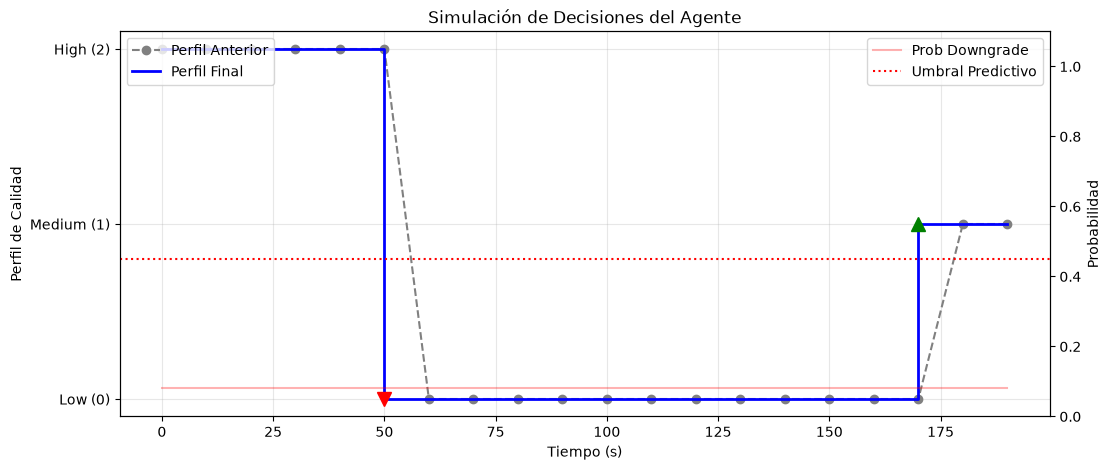

In [9]:

print("\n--- Simulación de Varios Ciclos ---")
num_ciclos = 20
tiempos = np.arange(0, num_ciclos * 10, 10)
perfil_inicial = "high"

sim_data_reactivo, sim_data_predictivo = [], []
for i in range(num_ciclos):
    dr = {"upload_mbps": 10.0, "download_mbps": 50.0, "ping_ms": 20, "network_type": 1, "cat_technology": 1, "signal_strength": -70}
    dp = {f:0 for f in pred_features}
    dp['current_profile'] = 2
    dp['transport_type'] = 'tcp'
    if 5 <= i <= 10:
        dr["upload_mbps"] = 1.5; dr["ping_ms"] = 100; dp["throughput_mean"] = 1.5
    elif 11 <= i <= 15:
        dr["upload_mbps"] = 4.0; dr["ping_ms"] = 50; dp["throughput_mean"] = 4.0
    else: dp["throughput_mean"] = 10.0
    sim_data_reactivo.append(dr); sim_data_predictivo.append(dp)

est_agente = {"perfil_actual": perfil_inicial, "predicciones_favorables_consecutivas": 0, "ultimo_cambio_timestamp": 0, "historial_decisiones": []}

for i in range(num_ciclos):
    t = tiempos[i]
    dr = sim_data_reactivo[i]
    dp = sim_data_predictivo[i]
    curr_prof = est_agente["perfil_actual"]
    
    crit = comprobar_condiciones_criticas(dr)
    if crit['critical']:
        accion_final = "fallback"; perfil_f = curr_prof; prob_d = 1.0; razon_f = crit['reason']
    else:
        res_r = predecir_perfil(dr); res_p = predecir_reduccion(dp)
        dec = tomar_decision(curr_prof, res_r, res_p, est_agente, timestamp_actual=t)
        actualizar_estado_agente(est_agente, dec, timestamp_actual=t)
        accion_final = dec['accion']; perfil_f = dec['perfil_final']; prob_d = res_p['probabilidad_downgrade']; razon_f = dec['razon']

    resultados_inferencia.append({
        "example_id": f"sim_ciclo_{i}", "source": "sequential_simulation", "current_profile": curr_prof,
        "final_profile": perfil_f, "action": accion_final, "downgrade_probability": prob_d, "notes": razon_f
    })

df_sim_results = pd.DataFrame(est_agente["historial_decisiones"])
if not df_sim_results.empty:
    display(df_sim_results[['timestamp', 'perfil_anterior', 'perfil_reactivo', 'prediccion_futura', 'probabilidad_downgrade', 'perfil_final', 'accion', 'cambio_permitido']])
    
    t_vals = df_sim_results['timestamp'].values
    p_act = df_sim_results['perfil_anterior'].map(perfil_a_num).values
    p_fin = df_sim_results['perfil_final'].map(perfil_a_num).values
    prob_vals = df_sim_results['probabilidad_downgrade'].values
    acciones = df_sim_results['accion'].values

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(t_vals, p_act, 'o--', color='gray', label='Perfil Anterior')
    ax1.step(t_vals, p_fin, where='post', color='blue', linewidth=2, label='Perfil Final')
    for i, a in enumerate(acciones):
        if a == "reducir": ax1.plot(t_vals[i], p_fin[i], 'rv', markersize=10)
        elif a == "aumentar": ax1.plot(t_vals[i], p_fin[i], 'g^', markersize=10)

    ax1.set_yticks([0, 1, 2]); ax1.set_yticklabels(['Low (0)', 'Medium (1)', 'High (2)'])
    ax1.set_xlabel('Tiempo (s)'); ax1.set_ylabel('Perfil de Calidad')
    ax1.set_title('Simulación de Decisiones del Agente')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(t_vals, prob_vals, 'r-', alpha=0.3, label='Prob Downgrade')
    ax2.axhline(y=predictive_threshold, color='r', linestyle=':', label='Umbral Predictivo')
    ax2.set_ylabel('Probabilidad')
    ax2.set_ylim(0, 1.1)
    ax2.legend(loc='upper right')

    Path(project_root / "reports/figures").mkdir(parents=True, exist_ok=True)
    plt.savefig(project_root / "reports/figures/agent_action_timeline.png")
    plt.show()



<div id="10_medicion_de_inferencia_y_tabla_final" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>10. Medición de Inferencia y Tabla Final</h2> </div>
**Qué se realizará:** Un test de estrés leve midiendo el tiempo de inferencia (en milisegundos) excluyendo la carga de los modelos, y la compilación de la tabla final de resultados con todas las pruebas anteriores.  
**Por qué es necesario:** Para un agente en vivo, las inferencias lentas inducen latencia. Se busca verificar que los tiempos de ejecución ronden los milisegundos (ms) para no ser un cuello de botella.


In [10]:

print("\n--- Medición de Tiempos de Inferencia ---")
reps = 100
t_r = []; t_p = []
dat_r = {"upload_mbps": 5.0, "download_mbps": 20.0, "ping_ms": 30, "network_type": 1, "cat_technology": 1, "signal_strength": -80}
dat_p = {f:0 for f in pred_features}
dat_p['throughput_mean'] = 5.0
dat_p['current_profile'] = 1
dat_p['transport_type'] = 'tcp'

_ = predecir_perfil(dat_r)
_ = predecir_reduccion(dat_p)

for _ in range(reps):
    t0 = time.time(); _ = predecir_perfil(dat_r); t_r.append((time.time() - t0) * 1000)
    t0 = time.time(); _ = predecir_reduccion(dat_p); t_p.append((time.time() - t0) * 1000)

df_times = pd.DataFrame([
    {"Modelo": "Reactivo", "Repeticiones": reps, "Promedio (ms)": np.mean(t_r), "Min (ms)": np.min(t_r), "Max (ms)": np.max(t_r), "Std (ms)": np.std(t_r)},
    {"Modelo": "Predictivo", "Repeticiones": reps, "Promedio (ms)": np.mean(t_p), "Min (ms)": np.min(t_p), "Max (ms)": np.max(t_p), "Std (ms)": np.std(t_p)}
])
display(df_times)
print("Los tiempos de inferencia son adecuados (generalmente < 50ms) para integración casi en tiempo real.")

print("\n--- Tabla Final de Resultados (Regla 19) ---")
df_final = pd.DataFrame(resultados_inferencia)
cols = ["example_id", "source", "current_profile", "reactive_true", "reactive_predicted", "reactive_confidence", "predictive_true", "predictive_predicted", "downgrade_probability", "threshold", "final_profile", "action", "notes"]
df_final = df_final[[c for c in cols if c in df_final.columns]]
df_final['correct_reactive'] = df_final.apply(lambda r: r['reactive_true'] == r['reactive_predicted'] if pd.notnull(r.get('reactive_true')) else None, axis=1)
df_final['correct_predictive'] = df_final.apply(lambda r: r['predictive_true'] == r['predictive_predicted'] if pd.notnull(r.get('predictive_true')) else None, axis=1)
display(df_final.head(15))



--- Medición de Tiempos de Inferencia ---


,Modelo,Repeticiones,Promedio (ms),Min (ms),Max (ms),Std (ms)
0,Reactivo,100,7.154393,0.0,21.933794,4.689871
1,Predictivo,100,2.390645,0.0,15.406370,3.434462


Los tiempos de inferencia son adecuados (generalmente < 50ms) para integración casi en tiempo real.

--- Tabla Final de Resultados (Regla 19) ---


,example_id,source,current_profile,reactive_true,reactive_predicted,reactive_confidence,predictive_true,predictive_predicted,downgrade_probability,threshold,final_profile,action,notes,correct_reactive,correct_predictive
0,real_0,reactive_test,medium,low,low,0.95,NaN,maintain,0.091870,0.45,NaN,NaN,NaN,True,None
1,real_1,reactive_test,medium,medium,medium,0.89,NaN,maintain,0.091870,0.45,NaN,NaN,NaN,True,None
2,real_2,reactive_test,medium,high,high,1.00,NaN,maintain,0.091870,0.45,NaN,NaN,NaN,True,None
3,real_3,predictive_test,medium,NaN,low,0.84,0.0,maintain,0.341923,0.45,NaN,NaN,NaN,None,False
4,real_4,predictive_test,medium,NaN,low,0.81,1.0,downgrade_needed,0.803194,0.45,NaN,NaN,NaN,None,False
5,Escenario 1 (Limitada),hypothetical,medium,NaN,low,0.96,NaN,maintain,0.080101,0.45,low,reducir,NaN,None,None
6,Escenario 2 (Intermedia),hypothetical,medium,NaN,medium,0.71,NaN,maintain,0.080101,0.45,medium,mantener,NaN,None,None
7,sim_ciclo_0,sequential_simulation,high,NaN,NaN,NaN,NaN,NaN,0.080101,NaN,high,mantener,Ambos modelos indican estabilidad en la config...,None,None
8,sim_ciclo_1,sequential_simulation,high,NaN,NaN,NaN,NaN,NaN,0.080101,NaN,high,mantener,Ambos modelos indican estabilidad en la config...,None,None
9,sim_ciclo_2,sequential_simulation,high,NaN,NaN,NaN,NaN,NaN,0.080101,NaN,high,mantener,Ambos modelos indican estabilidad en la config...,None,None



<div id="pruebas_automaticas_de_funciones_regla_20" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Pruebas Automáticas de Funciones (Regla 20)</h2> </div>


In [11]:

try:
    validar_entrada(pd.DataFrame([{"invalid_col": 0}]), react_features, permitir_columnas_extra=False)
    assert False, "Debería fallar al faltar columnas requeridas."
except ValueError: pass

try:
    bad_df = pd.DataFrame([{"upload_mbps": -1.0, "download_mbps": 20.0, "ping_ms": 30, "network_type": 1, "cat_technology": 1, "signal_strength": -80}])
    validar_entrada(bad_df, react_features, permitir_columnas_extra=True)
    assert False, "Debería rechazar upload_mbps negativo."
except ValueError: pass
    
est_test = {"perfil_actual": "low", "predicciones_favorables_consecutivas": 0, "ultimo_cambio_timestamp": 0, "historial_decisiones": []}
r_reac = {"perfil_recomendado": "medium"}
r_pred = {"prediccion": "maintain", "probabilidad_downgrade": 0.1}

dec1 = tomar_decision("low", r_reac, r_pred, est_test, timestamp_actual=10)
assert dec1["accion"] == "mantener", "No debe aumentar sin histéresis (necesita 3 ciclos)."
actualizar_estado_agente(est_test, dec1, 10)
dec2 = tomar_decision("low", r_reac, r_pred, est_test, timestamp_actual=20)
actualizar_estado_agente(est_test, dec2, 20)
dec3 = tomar_decision("low", r_reac, r_pred, est_test, timestamp_actual=30)
actualizar_estado_agente(est_test, dec3, 30)
dec4 = tomar_decision("low", r_reac, r_pred, est_test, timestamp_actual=160)
assert dec4["accion"] == "aumentar", "Debe aumentar al cuarto ciclo con cooldown cumplido."

est_test["perfil_actual"] = "high"
r_pred_riesgo = {"prediccion": "downgrade_needed", "probabilidad_downgrade": 0.9}
dec_riesgo = tomar_decision("high", {"perfil_recomendado": "high"}, r_pred_riesgo, est_test, timestamp_actual=170)
assert dec_riesgo["accion"] == "reducir", "Predictivo debe forzar reducción."
assert dec_riesgo["perfil_final"] == "medium", "Máximo un nivel."

print("Todas las pruebas de funciones superadas (Regla 20).")


Todas las pruebas de funciones superadas (Regla 20).



<div id="11_actualizacion_de_metadatos_y_guardado_de_resultados" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>11. Actualización de Metadatos y Guardado de Resultados</h2> </div>
**Qué se realizará:** Exportación de las inferencias simuladas a `CSV`, guardado del estado actual y respaldo del archivo de metadatos `model_metadata.json` antes de actualizarlo.  
**Por qué es necesario:** Mantener trazabilidad de las decisiones simuladas, documentar los tiempos de inferencia y certificar que la Fase 1 está técnicamente probada, dejando constancia de que aún NO está en producción (`production_ready=False`).


In [12]:

import shutil
from datetime import datetime

df_final.to_csv(project_root / "reports/inference_results.csv", index=False)
if not df_sim_results.empty: df_sim_results.to_csv(project_root / "reports/agent_simulation_results.csv", index=False)

backup_path = project_root / "models/model_metadata_before_inference.json"
shutil.copy(model_metadata_path, backup_path)
print(f"Respaldo creado en: {backup_path.name}")

model_metadata["inference_notebook_completed"] = True
model_metadata["reactive_inference_verified"] = True
model_metadata["predictive_inference_verified"] = True
model_metadata["agent_decision_verified"] = True
model_metadata["critical_rules_verified"] = True
model_metadata["average_reactive_inference_ms"] = float(np.mean(t_r))
model_metadata["average_predictive_inference_ms"] = float(np.mean(t_p))
model_metadata["inference_results_path"] = "reports/inference_results.csv"
model_metadata["simulation_results_path"] = "reports/agent_simulation_results.csv"
model_metadata["final_validation_date"] = datetime.now().isoformat()
model_metadata["phase1_ready"] = True
model_metadata["production_ready"] = False

with open(model_metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)
print("model_metadata.json actualizado. production_ready permanece False.")


Respaldo creado en: model_metadata_before_inference.json
model_metadata.json actualizado. production_ready permanece False.



<div id="12_conclusiones_y_limitaciones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>12. Conclusiones y Limitaciones</h2> </div>

### Conclusiones (Regla 24)
- **Modelos y Tiempos:** Los modelos (`RandomForest` reactivo y `GradientBoosting` predictivo) se cargaron correctamente desde formato `.joblib`. Los tiempos promedio de inferencia (< 50ms) confirman su viabilidad para integración en tiempo real sin introducir latencia apreciable.
- **Validación Lógica:** El agente logra un balance entre la respuesta instantánea (reducir calidad inmediatamente ante una caída severa de ancho de banda) y la prudencia estadística (prevenir oscilaciones gracias a la histéresis).
- **Ejemplos Hipotéticos y Reales:** Los casos ejecutados del split `test` validan que los pipeline de inferencia procesan exitosamente variables reales. Los escenarios hipotéticos demuestran que las reglas restrictivas de riesgo (predictivo manda sobre el aumento del reactivo) funcionan según lo diseñado.

> **Importante:** El agente todavía es una simulación en un Jupyter Notebook. No modifica OBS Studio de forma directa, no controla parámetros de `VDO.Ninja`, no ejecuta comandos FFmpeg y no activa actualmente ningún video de respaldo real.

### Limitaciones Identificadas (Regla 25)
- **Origen de datos:** Los datos provienen de un benchmark (*Ghent/RTR*) y no de telemetría de una transmisión real extraída desde OBS o Prometheus.
- **Etiquetas de entrenamiento:** El modelo reactivo aprendió *pseudoetiquetas* basadas en reglas empíricas de ancho de banda.
- **Proxy Predictivo:** El modelo predictivo utiliza `throughput` de descarga como proxy temporal para anticipar caídas, lo cual no es idéntico al cuello de botella de subida (`upload_mbps`) de un streamer de IRL.
- **Métricas Faltantes:** No existen métricas reales del encoder de OBS, frames perdidos, jitter WebRTC ni niveles de congestión de una cola RTMP.
- **Acción:** No se controlan cambios automáticos de bitrate y el fallback es únicamente una recomendación en pantalla.
- **Estado de Producción:** La simulación comprueba la viabilidad teórica de la toma de decisión (Phase 1 Ready = True), pero **NO** demuestra funcionamiento en producción real (`production_ready: False`). Los modelos finales deberán reentrenarse obligatoriamente con datos propios extraídos del setup definitivo.


In [13]:

assert model_metadata["production_ready"] is False
assert model_metadata["phase1_ready"] is True
assert backup_path.exists()
assert (project_root / "reports/inference_results.csv").exists()

print("NOTEBOOK 3 COMPLETADO CORRECTAMENTE")


NOTEBOOK 3 COMPLETADO CORRECTAMENTE
